In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from narwhals import read_csv

In [2]:
df = pd.read_csv("C:/Users/Taqi Saiyed/Downloads/Retail Data.csv")
df.head()

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
0,4293-1,02-09-2014,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,$156.50,$300.97,$144.47,23.0,"$4,533.52",2%,$194.83,"$4,757.22",$7.18,"$4,291.55"
1,5001-1,24-10-2015,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,$0.24,$1.26,$1.02,8.0,$45.20,3%,$0.00,$45.90,$0.70,$46.91
2,5004-1,13-03-2014,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,$42.11,$80.98,$38.87,45.0,$873.32,4%,$72.23,$837.57,$7.18,$82.58
3,5009-1,18-02-2013,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,$5.33,$8.60,$3.27,16.0,$73.52,1%,$4.35,$740.67,$6.19,$730.92
4,5010-1,13-09-2014,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,$1.53,$2.78,$1.25,49.0,$138.46,7%,$5.95,$123.77,$1.34,$125.97


In [3]:
print(list(df.columns))

['Order No', 'Order Date', 'Customer Name', 'Address', 'City', 'State', 'Customer Type', 'Account Manager', 'Order Priority', 'Product Name', 'Product Category', 'Product Container', 'Ship Mode', 'Ship Date', 'Cost Price', 'Retail Price', 'Profit Margin', 'Order Quantity', 'Sub Total', 'Discount %', 'Discount $', 'Order Total', 'Shipping Cost', 'Total']


In [4]:
#Ans1.
print(df.info())
print(df.dtypes)
print(df.isnull().sum())
#Displays all columns, data types, and missing values.
#Helps identify columns that need cleaning or conversion.

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order No           5000 non-null   str    
 1   Order Date         5000 non-null   str    
 2   Customer Name      5000 non-null   str    
 3   Address            4999 non-null   str    
 4   City               5000 non-null   str    
 5   State              5000 non-null   str    
 6   Customer Type      5000 non-null   str    
 7   Account Manager    5000 non-null   str    
 8   Order Priority     5000 non-null   str    
 9   Product Name       5000 non-null   str    
 10  Product Category   5000 non-null   str    
 11  Product Container  5000 non-null   str    
 12  Ship Mode          5000 non-null   str    
 13  Ship Date          5000 non-null   str    
 14  Cost Price         5000 non-null   str    
 15  Retail Price       5000 non-null   str    
 16  Profit Margin      5000 non-null   

In [5]:
#Ans2.
print("Shape:",df.shape)
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])
#Shows the total number of records and variables.
#Useful for understanding dataset size.

Shape: (5000, 24)
Rows: 5000
Columns: 24


In [6]:
#Ans3.
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)
#If duplicates exist, they should be removed before analysis.

Duplicate Records: 0


In [7]:
#Ans4.
cols = ['Order Date', 'Ship Date']
print(df[cols].isnull().sum())

a = df.select_dtypes(include='number').columns
print(df[a].isnull().sum())

#Missing dates or numeric values can affect calculations.
#Corrupted entries should be cleaned.

Order Date    0
Ship Date     0
dtype: int64
Order Quantity    1
dtype: int64


In [8]:
"""
Ans4. 2nd Method

cols = ['Order Date', 'Ship Date']

print(df[cols].isnull().sum())

numeric_cols = ['Cost Price','Retail Price','Profit Margin',
                'Order Quantity','Sub Total',
                'Discount $','Order Total',
                'Shipping Cost','Total']

print(df[numeric_cols].isnull().sum())
"""

"\nAns4. 2nd Method\n\ncols = ['Order Date', 'Ship Date']\n\nprint(df[cols].isnull().sum())\n\nnumeric_cols = ['Cost Price','Retail Price','Profit Margin',\n                'Order Quantity','Sub Total',\n                'Discount $','Order Total',\n                'Shipping Cost','Total']\n\nprint(df[numeric_cols].isnull().sum())\n"

In [9]:
#Ans5.
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')
print(df[['Order Date','Ship Date']].dtypes)
#Converts dates into datetime format for time-based analysis.

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [10]:
#Ans6.
future_orders = df[df['Order Date'] > pd.Timestamp.today()]

invalid_shipping = df[df['Ship Date'] < df['Order Date']]

print("Future Orders")
print(future_orders)

print("\nInvalid Shipping Dates")
print(invalid_shipping.loc[0,['Ship Date','Order Date']])
#Future order dates may indicate data-entry errors.
#Shipping before ordering is logically incorrect.

Future Orders
Empty DataFrame
Columns: [Order No, Order Date, Customer Name, Address, City, State, Customer Type, Account Manager, Order Priority, Product Name, Product Category, Product Container, Ship Mode, Ship Date, Cost Price, Retail Price, Profit Margin, Order Quantity, Sub Total, Discount %, Discount $, Order Total, Shipping Cost, Total]
Index: []

[0 rows x 24 columns]

Invalid Shipping Dates


KeyError: 0

In [11]:
#Ans7.
price_cols = ['Cost Price','Retail Price','Profit Margin',
              'Sub Total','Discount $',
              'Order Total','Shipping Cost','Total']

for col in price_cols:
    df[col] = (df[col]
               .astype(str)
               .str.replace('$','', regex=False)
               .str.replace(',','', regex=False))
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[price_cols].dtypes)
#Removes currency symbols and commas.
#Converts text into numeric values for calculations.

Cost Price       float64
Retail Price     float64
Profit Margin    float64
Sub Total        float64
Discount $       float64
Order Total      float64
Shipping Cost    float64
Total            float64
dtype: object


In [12]:
#Ans8.
print(df['Customer Type'].unique())
print("\n",df['Order Priority'].unique())
#Shows all customer categories and order priorities.

<StringArray>
['Small Business', 'Corporate', 'Consumer', 'Home Office']
Length: 4, dtype: str

 <StringArray>
['Critical', 'Medium', 'Not Specified', 'Low', 'High']
Length: 5, dtype: str


Ship Mode
Regular Air       4236
Express Air        647
Delivery Truck     117
Name: count, dtype: int64


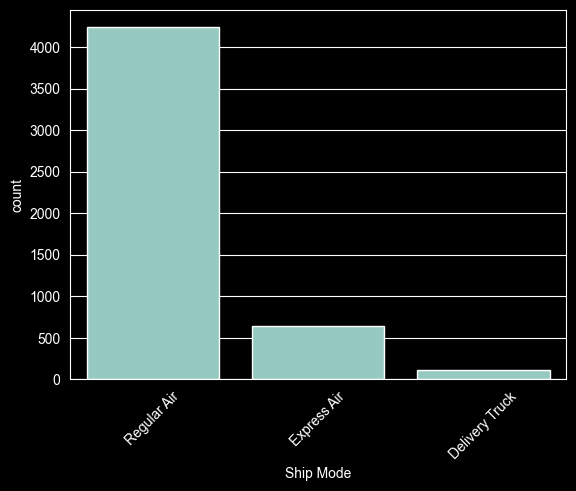

In [13]:
#Ans9.
df['Ship Mode'].value_counts()
print(df['Ship Mode'].value_counts())

sns.countplot(data=df, x='Ship Mode')
plt.xticks(rotation=45)
plt.show()
#Identifies the most frequently used shipping method.

In [14]:
#Example
b = [1,2,3,4,5,2,1,1,3,5]
c = int(input("Enter your choice from 1,2,3,4,5: "))
print(c,":",b.count(c))

4 : 1


In [15]:
#Sample
"""
d = df.groupby(['City'])['City'].value_counts().sort_values(ascending=False)
d

*****1st Method*****
d = df.groupby('City').size().reset_index(name='Count')

d = d.sort_values(by='Count', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(d['City'], d['Count'], align='center')
plt.xticks(rotation=45)
plt.xlabel("City")
plt.ylabel("Number of Banks")
plt.title("Number of Banks in Each City")
plt.show()

*****2nd Method*****
d = df['City'].value_counts().reset_index()
d.columns = ['City', 'Count']

plt.figure(figsize=(10, 5))
plt.bar(d['City'], d['Count'])
plt.xticks(rotation=45)
plt.xlabel("City")
plt.ylabel("Number of Banks")
plt.show()

"""


'\nd = df.groupby([\'City\'])[\'City\'].value_counts().sort_values(ascending=False)\nd\n\n*****1st Method*****\nd = df.groupby(\'City\').size().reset_index(name=\'Count\')\n\nd = d.sort_values(by=\'Count\', ascending=False)\n\nplt.figure(figsize=(10, 5))\nplt.bar(d[\'City\'], d[\'Count\'], align=\'center\')\nplt.xticks(rotation=45)\nplt.xlabel("City")\nplt.ylabel("Number of Banks")\nplt.title("Number of Banks in Each City")\nplt.show()\n\n*****2nd Method*****\nd = df[\'City\'].value_counts().reset_index()\nd.columns = [\'City\', \'Count\']\n\nplt.figure(figsize=(10, 5))\nplt.bar(d[\'City\'], d[\'Count\'])\nplt.xticks(rotation=45)\nplt.xlabel("City")\nplt.ylabel("Number of Banks")\nplt.show()\n\n'

City
Sydney       3584
Melbourne    1416
Name: count, dtype: int64


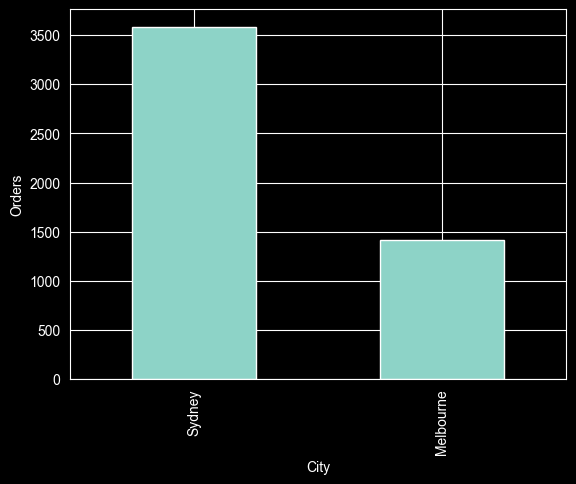

In [16]:
#Ans10.
city_orders = df['City'].value_counts()

print(city_orders.head(10))

city_orders.head(10).plot(kind='bar')
plt.ylabel("Orders")
plt.show()
#Highlights cities generating the highest sales volume.

In [17]:
#Ans11.
print(df[['Order Quantity','Retail Price']].describe())

print("Quantity Range:",
      df['Order Quantity'].min(),
      "to",
      df['Order Quantity'].max())

print("Retail Price Range:",
      df['Retail Price'].min(),
      "to",
      df['Retail Price'].max())
#Shows minimum, maximum, and average quantities and prices.

       Order Quantity  Retail Price
count     4999.000000   5000.000000
mean        26.483097     38.287266
std         14.391863     99.136522
min          1.000000      1.140000
25%         13.000000      2.940000
50%         27.000000      5.740000
75%         39.000000     19.980000
max         50.000000    599.990000
Quantity Range: 1.0 to 50.0
Retail Price Range: 1.14 to 599.99


In [18]:
#Ans12.
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df[['Order Date','Ship Date','Shipping Duration']].head())
#Calculates delivery time in days.
#Useful for logistics analysis.

  Order Date  Ship Date  Shipping Duration
0 2014-09-02 2014-09-04                  2
1 2015-10-24 2015-10-26                  2
2 2014-03-13 2014-03-13                  0
3 2013-02-18 2013-02-20                  2
4 2014-09-13 2014-09-17                  4


In [19]:
#Ans13.
invalid = df[(df['Order Quantity'] <= 0) | (df['Total'] <= 0)]

print(invalid)
#Such records may represent returns or incorrect entries.

Empty DataFrame
Columns: [Order No, Order Date, Customer Name, Address, City, State, Customer Type, Account Manager, Order Priority, Product Name, Product Category, Product Container, Ship Mode, Ship Date, Cost Price, Retail Price, Profit Margin, Order Quantity, Sub Total, Discount %, Discount $, Order Total, Shipping Cost, Total, Shipping Duration]
Index: []

[0 rows x 25 columns]


In [20]:
#Ans14.
expected_discount = df['Sub Total'] * (df['Discount %'].str.replace('%','').astype(float)/100)

mismatch = df[np.round(expected_discount,2) != np.round(df['Discount $'],2)]

print(mismatch[['Sub Total','Discount %','Discount $']])
#Identifies incorrect discount calculations.

      Sub Total Discount %  Discount $
0       4533.52         2%      194.83
1         45.20         3%        0.00
2        873.32         4%       72.23
3         73.52         1%        4.35
4        138.46         7%        5.95
...         ...        ...         ...
4995     115.40         2%       10.81
4996    1999.69         7%      143.91
4997     929.40         9%       27.88
4998      66.54         5%        4.46
4999     213.34         0%        4.67

[4775 rows x 3 columns]


In [21]:
#Ans15.
#Total = Order Total + Shipping Cost
expected_total = df['Order Total'] + df['Shipping Cost']

mismatch_total = df[np.round(expected_total,2) != np.round(df['Total'],2)]
mismatch_total['Expected_Total'] = mismatch_total['Order Total'] + mismatch_total['Shipping Cost']
#print(expected_total)
print(mismatch_total[['Order Total','Shipping Cost','Total','Expected_Total']])
#Finds records where the total amount is incorrect.

      Order Total  Shipping Cost    Total  Expected_Total
0         4757.22           7.18  4291.55         4764.40
1           45.90           0.70    46.91           46.60
2          837.57           7.18    82.58          844.75
3          740.67           6.19   730.92          746.86
4          123.77           1.34   125.97          125.11
...           ...            ...      ...             ...
4993        45.91           0.95    46.61           46.86
4994       851.97          11.28   852.47          863.25
4995       104.09           0.83   101.22          104.92
4996      1947.75          19.51  1052.55         1967.26
4997       901.52           1.99   921.03          903.51

[3832 rows x 4 columns]


                              Product Name  Order Quantity
0                       Artisan 474 Labels          3395.0
1        Smiths General Use 3-Ring Binders          3220.0
2                       Artisan 479 Labels          3039.0
3                       Artisan 481 Labels          2996.0
4  Apex Preferred Stainless Steel Scissors          2896.0


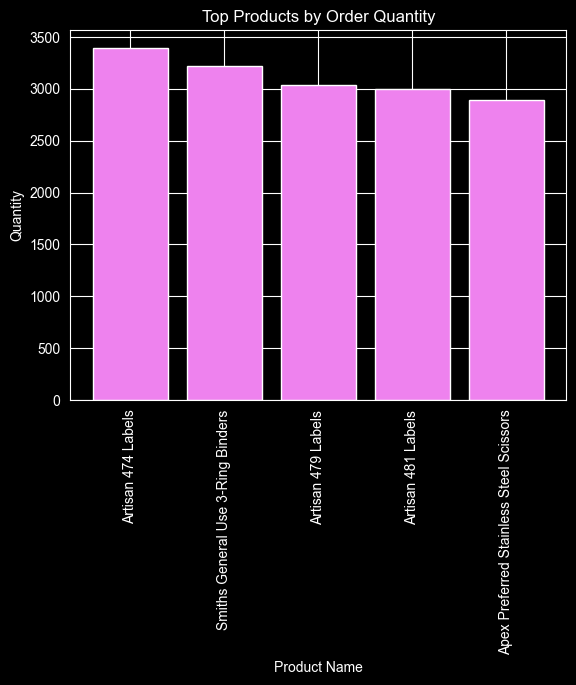

In [22]:
#Ans16.
top_product = df.groupby(['Product Name'])['Order Quantity'].sum().sort_values(ascending=False).head().reset_index()
print(top_product)
plt.bar(top_product['Product Name'], top_product['Order Quantity'], color='violet')
plt.title("Top Products by Order Quantity")
plt.xlabel("Product Name")
plt.ylabel("Quantity")
plt.xticks(rotation=90)
plt.show()
#Shows the highest-selling products by quantity.

In [23]:
#Ans17.
most_revenue = df.groupby(['Account Manager'])['Total'].sum().sort_values(ascending=False).head(10).reset_index()
print(most_revenue)
print("\nHighest Revenue Manager:")
print(most_revenue.iloc[0,0], most_revenue.iloc[0,1])

"""
most_revenue = df.groupby(['Account Manager'])['Total'].sum().sort_values(ascending=False).head(10)
print(most_revenue)
print("\nHighest Revenue Manager:")
print(most_revenue.idxmax(), most_revenue.max())
"""

      Account Manager      Total
0        Connor Betts  671173.17
1        Tina Carlton  453891.62
2         Yvette Biti  379687.12
3  Nicholas Fernandes  305927.88
4         Mihael Khan  281948.64
5     Samantha Chairs  273750.35
6         Phoebe Gour  249340.81
7        Natasha Song  242718.26
8         Aanya Zhang  241344.03
9    Leighton Forrest  216736.14

Highest Revenue Manager:
Connor Betts 671173.17


'\nmost_revenue = df.groupby([\'Account Manager\'])[\'Total\'].sum().sort_values(ascending=False).head(10)\nprint(most_revenue)\nprint("\nHighest Revenue Manager:")\nprint(most_revenue.idxmax(), most_revenue.max())\n'

        Ship Mode  Shipping Cost
0  Delivery Truck       5.270085
1     Express Air       5.247311
2     Regular Air       5.503553


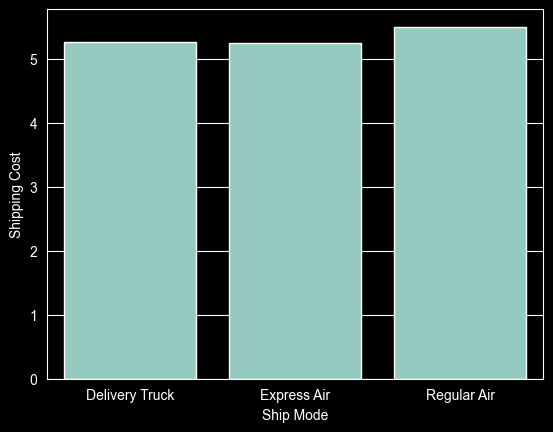

In [24]:
#Ans18.
cost = df.groupby(['Ship Mode'])['Shipping Cost'].mean().reset_index()
print(cost)
sns.barplot(data=cost,x=cost['Ship Mode'],y=cost['Shipping Cost'])
plt.show()
#Compares average shipping costs across different shipping modes.

In [25]:
#Ans19.
profit = df.groupby('Product Name')['Profit Margin'].sum().sort_values(ascending=False)

print(profit.head())

print("\nMost Profitable Product:")
print(profit.idxmax())

Product Name
Cando PC940 Copier                                17585.76
HFX LaserJet 3310 Copier                          10656.00
Adesso Programmable 142-Key Keyboard               7625.62
UGen Ultra Professional Cordless Optical Suite     6547.60
Deluxe Rollaway Locking File with Drawer           6163.30
Name: Profit Margin, dtype: float64

Most Profitable Product:
Cando PC940 Copier


In [26]:
#Ans20.
least_profit = df.groupby('Product Name')['Profit Margin'].sum().sort_values()

print(least_profit.head())

print("\nLeast Profitable Product:")
print(least_profit.idxmin())

Product Name
Sciths General Use 3-Ring Binders                   0.70
Artisan Binders                                     0.70
Artisan Reinforcements fot Hole-Punch Pages         0.79
Artisan Hole Reinforcements for Hole-Punch Pages    0.79
Bagred Suard Easer Clips                            1.02
Name: Profit Margin, dtype: float64

Least Profitable Product:
Sciths General Use 3-Ring Binders


In [27]:
"""
Understand Question 14,15
"""


'\nUnderstand Question 14,15\n'

Analysis Questions

In [28]:
df.head()

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total,Shipping Duration
0,4293-1,2014-09-02,Vivek Sundaresam,"152 Bunnerong Road,Eastgardens",Sydney,NSW,Small Business,Tina Carlton,Critical,UGen Ultra Professional Cordless Optical Suite,...,300.97,144.47,23.0,4533.52,2%,194.83,4757.22,7.18,4291.55,2
1,5001-1,2015-10-24,Shahid Hopkins,"438 Victoria Avenue,Chatswood",Sydney,NSW,Corporate,Natasha Song,Medium,Bagged Rubber Bands,...,1.26,1.02,8.0,45.20,3%,0.00,45.90,0.70,46.91,2
2,5004-1,2014-03-13,Dennis Pardue,"412 Brunswick St,Fitzroy",Melbourne,VIC,Consumer,Connor Betts,Not Specified,TechSavi Cordless Navigator Duo,...,80.98,38.87,45.0,873.32,4%,72.23,837.57,7.18,82.58,0
3,5009-1,2013-02-18,Sean Wendt,"145 Ramsay St,Haberfield",Sydney,NSW,Small Business,Phoebe Gour,Critical,Artisan Printable Repositionable Plastic Tabs,...,8.60,3.27,16.0,73.52,1%,4.35,740.67,6.19,730.92,2
4,5010-1,2014-09-13,Christina Vanderzanden,"188 Pitt Street,Sydney",Sydney,NSW,Small Business,Tina Carlton,Not Specified,Pizazz Drawing Pencil Set,...,2.78,1.25,49.0,138.46,7%,5.95,123.77,1.34,125.97,4


In [29]:
print(df.columns)

Index(['Order No', 'Order Date', 'Customer Name', 'Address', 'City', 'State',
       'Customer Type', 'Account Manager', 'Order Priority', 'Product Name',
       'Product Category', 'Product Container', 'Ship Mode', 'Ship Date',
       'Cost Price', 'Retail Price', 'Profit Margin', 'Order Quantity',
       'Sub Total', 'Discount %', 'Discount $', 'Order Total', 'Shipping Cost',
       'Total', 'Shipping Duration'],
      dtype='str')


In [30]:
#Ans1.
total_revenue = df['Total'].sum()
print("Total Revenue:", np.round(total_revenue,1))
#Shows the total sales revenue generated from all orders.

Total Revenue: 3731536.4


In [31]:
#Ans2.
customer_revenue = df.groupby('Customer Type')['Total'].sum().sort_values(ascending=False)
customer_revenue
#Identifies which customer segment contributes the highest revenue.

Customer Type
Corporate         1373796.44
Home Office        851621.96
Small Business     830886.35
Consumer           675231.65
Name: Total, dtype: float64

In [32]:
#Ans3.
affect_revenue = df.groupby(['Order Priority'])['Total'].sum().sort_values(ascending=False)
affect_revenue
#Compares total revenue generated by each order priority level.

Order Priority
Not Specified    817844.66
High             794199.00
Medium           784744.63
Critical         694547.97
Low              640200.14
Name: Total, dtype: float64

In [33]:
#Ans4.
category_profit = df.groupby('Product Category')['Profit Margin'].mean().sort_values(ascending=False)
print(category_profit)
#Shows which product category earns the highest average profit margin.

Product Category
Technology         20.423208
Office Supplies    17.682609
Furniture          12.701953
Name: Profit Margin, dtype: float64


In [34]:
#Ans5.
profit_product = df.groupby('Product Name')['Profit Margin'].sum().sort_values(ascending=False)

print(profit_product.head())

print("\nMost Profitable Product:")
print(profit_product.idxmax(), "-", profit_product.max())
#Finds the product that generates the highest total profit.

Product Name
Cando PC940 Copier                                17585.76
HFX LaserJet 3310 Copier                          10656.00
Adesso Programmable 142-Key Keyboard               7625.62
UGen Ultra Professional Cordless Optical Suite     6547.60
Deluxe Rollaway Locking File with Drawer           6163.30
Name: Profit Margin, dtype: float64

Most Profitable Product:
Cando PC940 Copier - 17585.760000000002


In [35]:
#Ans6.
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df['Shipping Duration'].describe())

print("Average Shipping Days:", df['Shipping Duration'].mean())

count    5000.000000
mean        1.835600
std        20.371725
min      -365.000000
25%         1.000000
50%         2.000000
75%         2.000000
max       370.000000
Name: Shipping Duration, dtype: float64
Average Shipping Days: 1.8356


In [36]:
#Ans7.
correlation = df['Shipping Duration'].corr(df['Profit Margin'])

print("Correlation:", correlation)
"""
A positive correlation means longer shipping is associated with higher profit margins.
A negative correlation means longer shipping is associated with lower profit margins.
A value close to 0 indicates little or no relationship.
"""

Correlation: -0.01978703518675133


'\nA positive correlation means longer shipping is associated with higher profit margins.\nA negative correlation means longer shipping is associated with lower profit margins.\nA value close to 0 indicates little or no relationship.\n'

In [37]:
#Ans8.
city_revenue = df.groupby('City')['Total'].sum().sort_values(ascending=False)

print(city_revenue.head())

print("\nHighest Revenue City:")
print(city_revenue.idxmax(), "-", city_revenue.max())
#Identifies the city contributing the most revenue.

City
Sydney       2678780.33
Melbourne    1052756.07
Name: Total, dtype: float64

Highest Revenue City:
Sydney - 2678780.33


In [38]:
#Ans9.
manager_revenue = df.groupby('Account Manager')['Total'].sum().sort_values(ascending=False)

print(manager_revenue)

print("\nHighest Revenue Manager:")
print(manager_revenue.idxmax(), "-", manager_revenue.max())
#Finds the account manager with the highest total sales.

Account Manager
Connor Betts          671173.17
Tina Carlton          453891.62
Yvette Biti           379687.12
Nicholas Fernandes    305927.88
Mihael Khan           281948.64
Samantha Chairs       273750.35
Phoebe Gour           249340.81
Natasha Song          242718.26
Aanya Zhang           241344.03
Leighton Forrest      216736.14
Preston Senome        199052.07
Charlie Bui           138153.12
Radhya Staples         61519.53
Stevie Bacata          15879.22
Eanya Zhang              240.69
Oanya Zhang               73.57
Simantha Chairs           55.12
Wicholas Fernandes        39.99
Charlie Buo                5.07
Name: Total, dtype: float64

Highest Revenue Manager:
Connor Betts - 671173.17


In [39]:
#Ans10.
shipping_cost = df.groupby('Ship Mode')['Shipping Cost'].mean().sort_values()

print(shipping_cost)

print("\nMost Cost-Effective Shipping Mode:")
print(shipping_cost.idxmin(), "-", shipping_cost.min())
#Shows which shipping mode has the lowest average shipping cost.

Ship Mode
Express Air       5.247311
Delivery Truck    5.270085
Regular Air       5.503553
Name: Shipping Cost, dtype: float64

Most Cost-Effective Shipping Mode:
Express Air - 5.247310664605873


In [42]:
#Ans11.
discount_profit = df[['Discount %','Profit Margin']].copy()

discount_profit['Discount %'] = discount_profit['Discount %'].str.replace('%','').astype(float)

correlation = discount_profit['Discount %'].corr(discount_profit['Profit Margin'])

print("Correlation:", correlation)
#A negative correlation suggests that higher discounts reduce profit margins.
#A positive correlation suggests that higher discounts do not necessarily reduce profits.

Correlation: -0.026044066258333182


In [48]:
#Ans12.
state_orders = df['State'].value_counts()

print(state_orders)

print("\nHighest Orders State:")
print(state_orders.idxmax(), "-", state_orders.max())
#Identifies the state with the greatest number of orders.

State
NSW    3584
VIC    1416
Name: count, dtype: int64

Highest Orders State:
NSW - 3584


In [49]:
#Ans13.
df['Discount %'] = df['Discount %'].str.replace('%','').astype(float)

print("Average Discount %:", df['Discount %'].mean())
#Calculates the average discount percentage given across all orders.

Average Discount %: 5.0338


In [51]:
#Ans14.
average_spend = df['Total'].mean()
print("Average Total Spend:", average_spend)
#Shows the average amount spent per order.

Average Total Spend: 746.3072800000001


In [63]:
#Ans15.
container = df.groupby(['Product Container'])['Profit Margin'].sum().sort_values(ascending=False).reset_index()
#container.columns = ['Container','Profit']
container
#Compares total profit generated by each container type.
#Helps identify the most profitable packaging option.

,Product Container,Profit Margin
0,Small Box,50941.29
1,Wrap Bag,24151.13
2,Small Pack,9613.91
3,Jumbo Drum,1928.56
4,Medium Box,1704.49
5,Large Box,1640.92


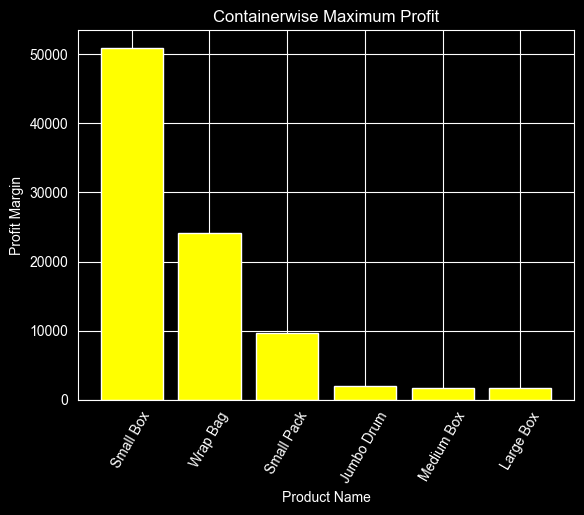

In [76]:
plt.bar(container['Product Container'], container['Profit Margin'], color="yellow")
plt.title("Containerwise Maximum Profit")
plt.xlabel("Product Name")
plt.ylabel("Profit Margin")
plt.xticks(rotation=60)
plt.show()